In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
mrl_isoform = np.load( path + 'mrl_isoform_resolved.npz')

In [3]:
investigate_dataset(mrl_isoform)

['X', 'y', 'genes']

Array shapes:
X shape: (11693, 12288, 6)
y shape: (11693,)
genes shape: (11693,)

First few y values: [5.40141546 3.33709259 5.41937329 5.74227841 5.32184319]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [1. 0. 0. 0. 0.]


In [4]:
pca_embeddings = create_embedding_dataframe(mrl_isoform['X'], mrl_isoform['genes'])
pca_embeddings

PCA embeddings shape: (11693, 2048)
Total explained variance by PCA 72.13%


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.865396,0.079596,0.481374,-0.104772,0.212947,0.451532,-0.134442,-0.150223,-0.260685,0.452143
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.263763,-0.885778,-0.502246,-0.353128,1.275956,0.907496,-1.200351,0.793998,0.523489,-0.670373
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.420846,0.164549,0.527038,-0.372807,-0.479889,0.024580,-0.029325,-1.112629,-0.021421,-0.401716
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.006707,-0.104171,-0.877709,-0.683156,-0.005283,0.362623,-0.167594,0.469137,0.153478,-0.158024
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,0.145344,-0.764565,0.287612,-0.708179,1.228626,0.793176,0.381995,0.487444,0.625306,-0.149675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,-0.193864,-0.076030,0.129630,-0.047593,0.180943,0.309724,0.013042,0.291061,0.225585,0.025651
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579754,...,0.729080,-0.497877,-1.347704,0.131287,0.240605,-0.433204,0.867656,0.061326,0.910957,-1.158474
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,-0.569748,-0.260349,-0.499208,-0.230038,-0.395500,-0.103256,0.198844,0.525481,-0.226753,0.604811


In [5]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [ ]:
cancer_gene_columns = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(cancer_gene_columnss, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.212947,0.451532,-0.134442,-0.150223,-0.260685,0.452143,False,False,False,False
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,1.275956,0.907496,-1.200351,0.793998,0.523489,-0.670373,False,False,False,False
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,-0.479889,0.024580,-0.029325,-1.112629,-0.021421,-0.401716,False,False,False,False
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.005283,0.362623,-0.167594,0.469137,0.153478,-0.158024,False,False,False,False
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,1.228626,0.793176,0.381995,0.487444,0.625306,-0.149675,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCO2,-11.021691,-8.526528,-5.202515,-2.475116,-1.106725,-2.811286,7.074593,0.870503,3.028499,-0.628025,...,-0.010865,-0.577311,-0.174894,-0.137065,-0.053693,-0.196699,False,False,False,False
TBCE,-3.199916,-0.195192,13.523295,6.196819,-5.897826,-0.775914,0.624610,1.177227,2.232309,3.613913,...,0.116242,-0.215868,-0.544126,-0.087637,-1.683974,-0.308222,False,False,False,False
ABCF2,16.090095,17.135822,-9.145933,4.259971,6.373613,1.688988,-0.188709,2.161776,3.379265,-0.509944,...,0.723378,0.161247,0.941183,1.037382,0.624735,-0.528612,False,True,False,False


## Predict NCG_Known_Cancer_Gene

In [7]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    5610
True      331
Name: count, dtype: int64

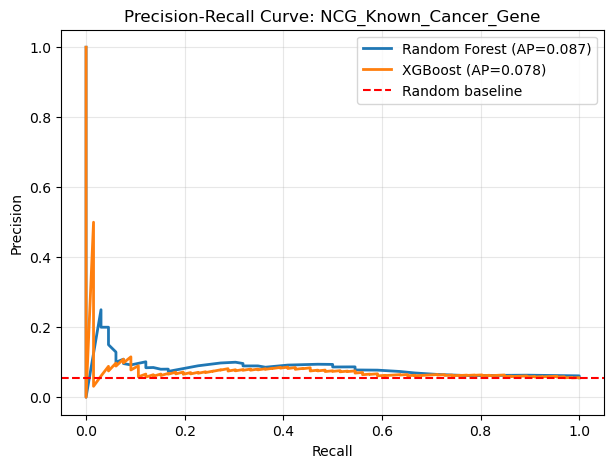

Random Forest - auPRC: 0.087
XGBoost - auPRC: 0.078



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [9]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    5450
True      491
Name: count, dtype: int64

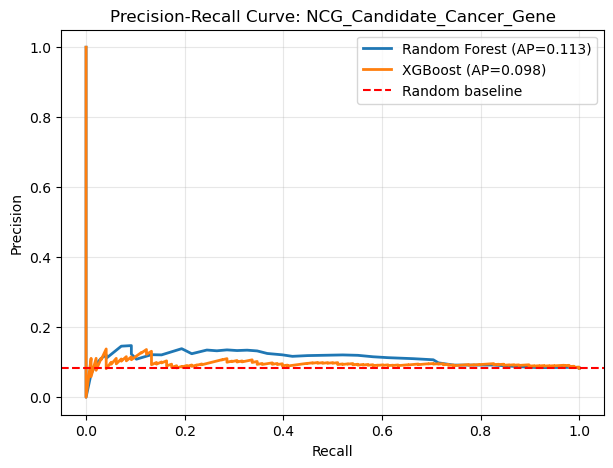

Random Forest - auPRC: 0.113
XGBoost - auPRC: 0.098



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [11]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    5675
True      266
Name: count, dtype: int64

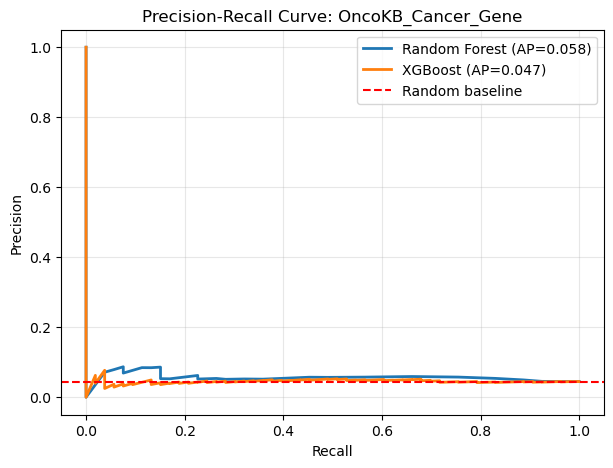

Random Forest - auPRC: 0.058
XGBoost - auPRC: 0.047



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [13]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    5788
True      153
Name: count, dtype: int64

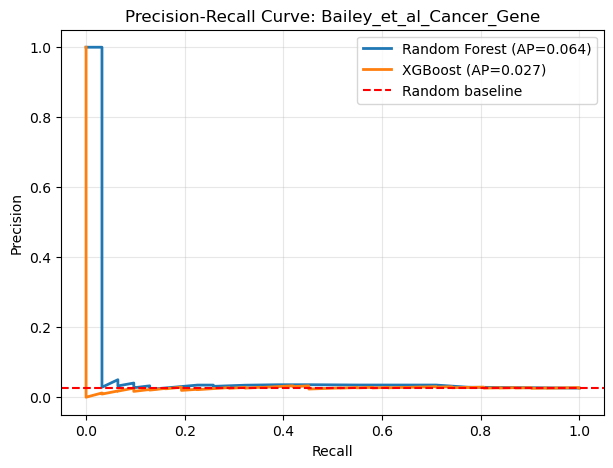

Random Forest - auPRC: 0.064
XGBoost - auPRC: 0.027



In [14]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')